<center> <H1> GLOBAL MARKET FOOD PRICES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
food_df = pd.read_csv("wfp_market_food_prices.csv", encoding='latin-1')

In [ ]:
food_df.head(10)

,adm0_id,adm0_name,adm1_id,adm1_name,mkt_id,mkt_name,cm_id,cm_name,cur_id,cur_name,pt_id,pt_name,um_id,um_name,mp_month,mp_year,mp_price,mp_commoditysource
0,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,1,2014,50.0,WFP
1,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,2,2014,50.0,WFP
2,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,3,2014,50.0,WFP
3,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,4,2014,50.0,WFP
4,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,5,2014,50.0,WFP
5,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,6,2014,50.0,WFP
6,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,7,2014,50.0,WFP
7,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,8,2014,50.0,WFP
8,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,9,2014,50.0,WFP
9,1,Afghanistan,272,Badakhshan,266,Fayzabad,55,Bread,87,AFN,15,Retail,5,KG,10,2014,50.0,WFP


In [ ]:
print(food_df["adm0_name"].unique())

['Afghanistan' 'Algeria' 'Armenia' 'Azerbaijan' 'Bangladesh' 'Benin'
 'Bhutan' 'Bolivia' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon'
 'Cape Verde' 'Central African Republic' 'Chad' 'Colombia' 'Congo'
 'Costa Rica' "Cote d'Ivoire" 'Democratic Republic of the Congo'
 'Djibouti' 'El Salvador' 'Ethiopia' 'Gambia' 'Georgia' 'Ghana'
 'Guatemala' 'Guinea-Bissau' 'Guinea' 'Haiti' 'Honduras' 'India'
 'Indonesia' 'Iran  (Islamic Republic of)' 'Iraq' 'Jordan' 'Kenya'
 'Kyrgyzstan' "Lao People's Democratic Republic" 'Lebanon' 'Lesotho'
 'Liberia' 'Madagascar' 'Malawi' 'Mali' 'Mauritania' 'Mozambique'
 'Myanmar' 'Nepal' 'Niger' 'Nigeria' 'Pakistan' 'Panama' 'Peru'
 'Philippines' 'Rwanda' 'Senegal' 'Somalia' 'Sri Lanka' 'Swaziland'
 'Syrian Arab Republic' 'Tajikistan' 'Timor-Leste' 'Turkey' 'Uganda'
 'Ukraine' 'United Republic of Tanzania' 'Yemen' 'Zambia' 'Zimbabwe'
 'State of Palestine' 'Sudan' 'Egypt' 'South Sudan']


* These are all the countries that are present in the dataset

In [ ]:
food_df.describe()

,adm0_id,adm1_id,mkt_id,cm_id,cur_id,pt_id,um_id,mp_month,mp_year,mp_price
count,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,743914.000000,7.439140e+05
mean,929.754832,17779.426232,885.962341,161.130914,57.325319,14.930508,10.562171,6.379772,2012.516549,4.196333e+03
std,6595.353806,81345.242217,540.492854,117.826297,23.140366,0.277872,13.160485,3.434972,3.669519,5.549296e+04
min,1.000000,0.000000,80.000000,50.000000,22.000000,14.000000,5.000000,1.000000,1992.000000,0.000000e+00
25%,115.000000,1510.000000,377.000000,67.000000,30.000000,15.000000,5.000000,3.000000,2011.000000,3.000000e+01
50%,170.000000,2207.000000,912.000000,110.000000,63.000000,15.000000,5.000000,6.000000,2013.000000,1.750000e+02
75%,205.000000,21969.000000,1134.000000,233.000000,77.000000,15.000000,5.000000,9.000000,2015.000000,5.000000e+02
max,70001.000000,900022.000000,2094.000000,490.000000,95.000000,18.000000,100.000000,12.000000,2017.000000,5.833333e+06


In [ ]:
missing = food_df.isnull().sum()
percentage = round(missing/len(food_df)*100)
print("missing percentage:-\n \n",percentage,"\n")

missing percentage:-
 
 adm0_id               0.0
adm0_name             0.0
adm1_id               0.0
adm1_name             2.0
mkt_id                0.0
mkt_name              0.0
cm_id                 0.0
cm_name               0.0
cur_id                0.0
cur_name              0.0
pt_id                 0.0
pt_name               0.0
um_id                 0.0
um_name               0.0
mp_month              0.0
mp_year               0.0
mp_price              0.0
mp_commoditysource    0.0
dtype: float64 



* We can see the mising values in only adm1_name which is state name in a country.
* Which is only 2 percent, So we can remove it.

In [ ]:
food_df = food_df.dropna()

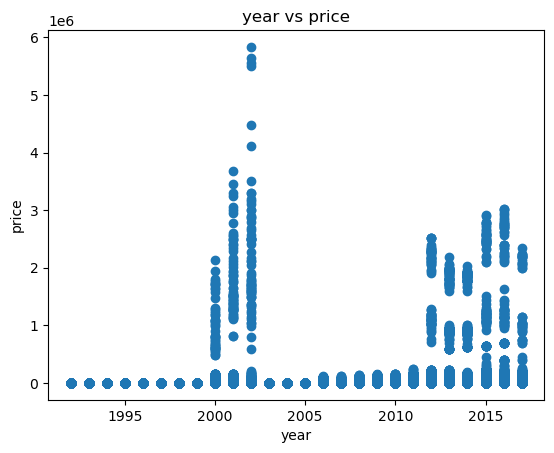

In [ ]:
x = food_df['mp_year']
y = food_df['mp_price']
plt.scatter(x,y)
plt.xlabel('year')
plt.ylabel('price')
plt.title('year vs price')
plt.show()

In [ ]:
meat_subset = food_df[food_df['cm_name'].str.contains('meat', case=False)]

/var/folders/6d/v8vndbf12fgg242y8718s65c0000gn/T/ipykernel_14366/762153925.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('tab20')


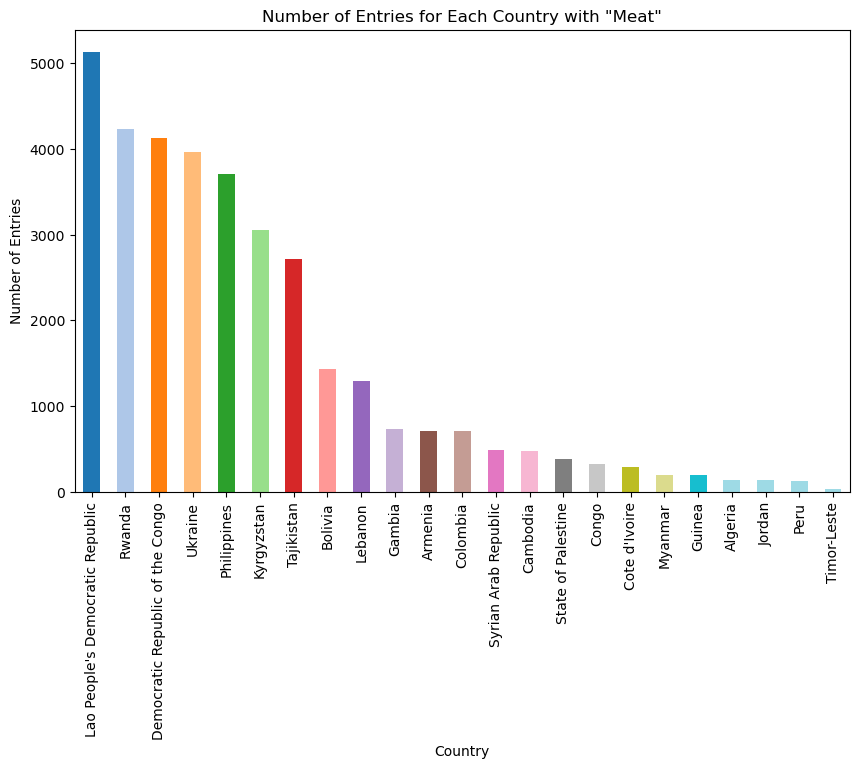

In [ ]:
country_counts = meat_subset['adm0_name'].value_counts()
cmap = get_cmap('tab20')
country_counts.plot(kind='bar', figsize=(10, 6), color=cmap(range(len(country_counts))))
plt.title('Number of Entries for Each Country with "Meat"')
plt.xlabel('Country')
plt.ylabel('Number of Entries')
plt.show()

* We can see that Lao people's Democratic Republic consumes more meat than all other countries.
* Timor-Leste consumes less meat than all the countries.

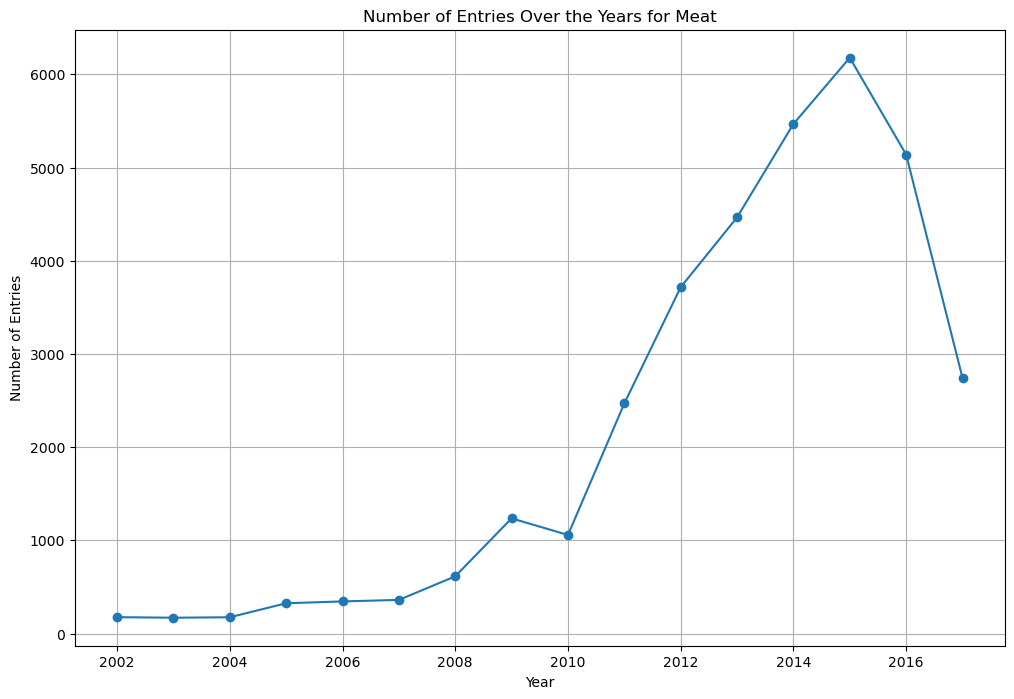

In [ ]:
country_year_counts = meat_subset.groupby('mp_year').size()
country_year_counts.plot(kind='line', marker='o', figsize=(12, 8))
plt.title('Number of Entries Over the Years for Meat')
plt.xlabel('Year')
plt.ylabel('Number of Entries')
plt.grid(True)
plt.show()

In [ ]:
print(food_df["pt_name"].unique())

['Retail' 'Wholesale' 'Producer' 'Farm Gate']


* These are different types sales

In [ ]:
category_counts = food_df["pt_name"].value_counts()
category_counts

pt_name
Retail       676155
Wholesale     52918
Farm Gate       664
Producer        228
Name: count, dtype: int64

* These are the count of the sales for each type os sale.
* We can see that Most number of sales are done from Retail stores.

* Using Lable Encoder for for converting categorical columns into numerical columns

In [ ]:
food_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 729965 entries, 0 to 743913
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   adm0_id             729965 non-null  int64  
 1   adm0_name           729965 non-null  object 
 2   adm1_id             729965 non-null  int64  
 3   adm1_name           729965 non-null  object 
 4   mkt_id              729965 non-null  int64  
 5   mkt_name            729965 non-null  object 
 6   cm_id               729965 non-null  int64  
 7   cm_name             729965 non-null  object 
 8   cur_id              729965 non-null  int64  
 9   cur_name            729965 non-null  object 
 10  pt_id               729965 non-null  int64  
 11  pt_name             729965 non-null  object 
 12  um_id               729965 non-null  int64  
 13  um_name             729965 non-null  object 
 14  mp_month            729965 non-null  int64  
 15  mp_year             729965 non-null  in

In [ ]:
le = LabelEncoder()
food_df['adm0_name'] = le.fit_transform(food_df['adm0_name'])
food_df['adm1_name'] = le.fit_transform(food_df['adm1_name'])
food_df['mkt_name'] = le.fit_transform(food_df['mkt_name'])
food_df['cm_name'] = le.fit_transform(food_df['cm_name'])
food_df['cur_name'] = le.fit_transform(food_df['cur_name'])
food_df['pt_name'] = le.fit_transform(food_df['pt_name'])
food_df['um_name'] = le.fit_transform(food_df['um_name'])
food_df['mp_commoditysource'] = le.fit_transform(food_df['mp_commoditysource'])

## Applying Random Forest for price analysis

In [ ]:
X=food_df.drop('mp_price',axis=1)
y = food_df['mp_price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Random Forest r2 value taking all features into consideration:",r2)

Random Forest r2 value taking all features into consideration: 0.9947682756775595


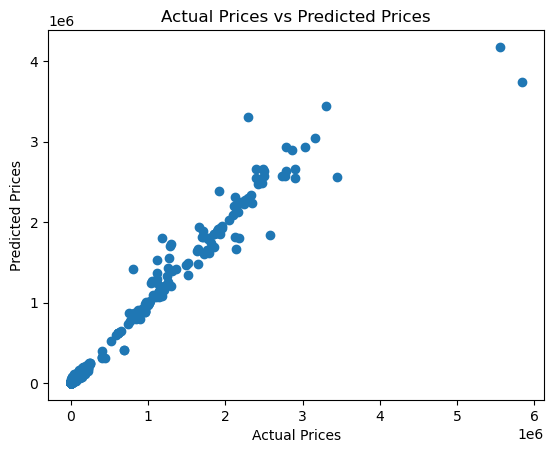

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs Predicted Prices')
plt.show()

* This is an Ideal Scenario indicating the perfect fit between actual and predicted prices.
* There are two outliers in the data set

# References
* Dataset is taken from Kaggle
* link :- https://www.kaggle.com/datasets/jboysen/global-food-prices